In [ ]:
from typing import Literal, TypedDict

from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()

True

# Simple 

In [19]:
class QuadraticState(TypedDict):
    
    a: int
    b: int
    c: int
    
    equation: str
    discriminant: float
    result: str

In [25]:
def show_equation(state: QuadraticState) -> QuadraticState:
    
    equation= f'{state['a']}x^2  {state['b']}x  {state['c']}'
    return {'equation': equation}

def calculate_discriminant(state: QuadraticState) -> QuadraticState:
    
    discriminant= state['b']**2 - (4*state['a']*state['c'])
    return {'discriminant': discriminant}

def real_roots(state: QuadraticState) -> QuadraticState:
    
    x1= (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    x2= (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    return {'result': f'real roots: root1={x1}, root2={x2}'}

def repeating_roots(state: QuadraticState) -> QuadraticState:
    
    x= -state['b'] / (2*state['a'])
    return {'result': f'repeating roots={x}'}

def no_real_roots(state: QuadraticState) -> QuadraticState:
    
    return {'result': 'no real roots'}

def check_condition(state: QuadraticState) -> Literal['real_roots', 'repeating_roots', 'no_real_roots']:
    
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeating_roots'
    else:
        return 'no_real_roots'

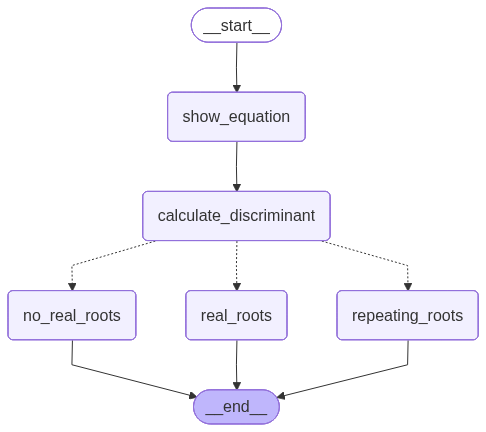

In [27]:
graph= StateGraph(QuadraticState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeating_roots', repeating_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeating_roots', END)
graph.add_edge('no_real_roots', END)

workflow= graph.compile()
workflow

In [32]:
initial_state= {
    'a': 5,
    'b': 5,
    'c': -1
}

result= workflow.invoke(initial_state)
result

{'a': 5,
 'b': 5,
 'c': -1,
 'equation': '5x^2  5x  -1',
 'discriminant': 45,
 'result': 'real roots: root1=0.17082039324993695, root2=-1.170820393249937'}

# Including LLM

In [42]:
model= ChatMistralAI(model= 'mistral-small-latest')

In [43]:
class ReviewReply(TypedDict):
    
    review: str
    review_sentiment: Literal['positive', 'negative']
    diagnosis: str
    reply: str

In [44]:
class Sentiment(BaseModel):
    
    sentiment: Literal['positive', 'negative']= Field(description='give the sentiment of the review text')

In [45]:
structured_model= model.with_structured_output(Sentiment)

In [61]:
def find_sentiment(state: ReviewReply) -> ReviewReply:
    
    review_sentiment= structured_model.invoke(f'What is the sentiment of the following review: {state["review"]}').sentiment
    return {'review_sentiment': review_sentiment}

def run_diagnosis(state: ReviewReply) -> ReviewReply:
    
    diagnosis= model.invoke(f'What is the main issue of the following review: {state["review"]}').content
    return {'diagnosis': diagnosis}

def negative_response(state: ReviewReply) -> ReviewReply:
    
    reply= model.invoke(f'Kindly draft an appropriate reply to the following negative review: {state["review"]} with the following main issue: {state["diagnosis"]}. \nOnly provide the reply without any additional jargon.').content
    return {'reply': reply}

def positive_response(state: ReviewReply) -> ReviewReply:
    
    reply= model.invoke(f'Kindly draft an appropriate reply to the following positive review: {state["review"]}. Only provide the reply without any additional jargon.').content
    return {'reply': reply}

def check_condition(state: ReviewReply) -> Literal['run_diagnosis', 'positive_response']:
    
    if state['review_sentiment'] == 'negative':
        return 'run_diagnosis'
    else:
        return 'positive_response'

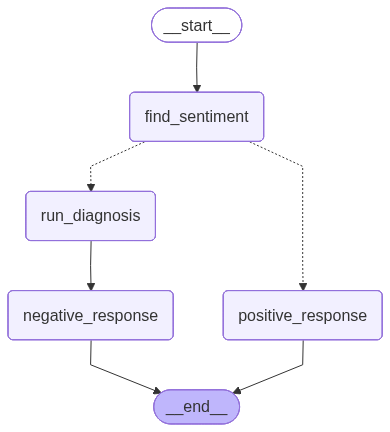

In [62]:
graph= StateGraph(ReviewReply)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)
graph.add_node('positive_response', positive_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_condition)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)
graph.add_edge('positive_response', END)

workflow= graph.compile()
workflow

In [65]:
initial_state= {
    'review': 'I recently visited this spot and was absolutely blown away! The service was top-notch—friendly, attentive, and incredibly fast. The quality exceeded my expectations, and the atmosphere was cozy and welcoming. I highly recommend trying it out, I’ll definitely be returning soon. This place truly deserves all the praise!'
}

final_state= workflow.invoke(initial_state)

In [66]:
print(final_state['reply'])

Thank you so much for your wonderful review! We're thrilled to hear that you had such a great experience and that you'll be back. We truly appreciate your support and kind words.


In [68]:
initial_state= {
    'review': 'Extremely disappointed with this service. The staff was rude and unprofessional, and the product I received was damaged. It took over three weeks to arrive, and customer support was completely unresponsive to my emails. I wasted my money and time. Definitely do not recommend—look elsewhere for a better experience.'
}

final_state= workflow.invoke(initial_state)

In [70]:
print(final_state['diagnosis'])
print('-'*50)
print(final_state['reply'])

The main issues highlighted in the review are:

1. **Rude and Unprofessional Staff** – The customer experienced poor behavior from the service staff.
2. **Damaged Product** – The item they received was not in good condition.
3. **Delayed Delivery** – The product took over three weeks to arrive, which is much longer than expected.
4. **Unresponsive Customer Support** – The customer had difficulty getting help via email.

Overall, the review expresses **extreme dissatisfaction** with the service, leading the customer to advise others to avoid it. The key takeaway is that the experience was **poor in terms of product quality, delivery time, and customer service**.
--------------------------------------------------
We sincerely apologize for the poor experience you had with our service. We take your feedback seriously and are truly disappointed to hear about the issues you encountered. This is not the level of service we strive to provide, and we would like to make this right.

We will add